In [1]:
import os 
import requests

pdf_path = "human-nutrition-text.pdf"

if not os.path.exists(pdf_path):
    print("File does not exist, downloading...")

    url = "https://pressbooks.oer.hawaii.edu/humannutrition2/open/download?type=pdf"

    filename = pdf_path

    response = requests.get(url)

    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"The file was downloaded successfully as {filename}")

    else:
        print("Failed to download the file")

In [2]:
import fitz
from tqdm.auto import tqdm

def text_formatter(text):
    cleaned_text = text.replace("\n", " ").strip()

    return cleaned_text

def open_and_read_pdf(pdf_path):
    doc = fitz.open(pdf_path)

    pages_and_texts = []

    for page_number, page in tqdm(enumerate(doc)):
        text = page.get_text()
        text = text_formatter(text)

        pages_and_texts.append({
            "page_number": page_number - 41,
            "page_char_count": len(text),
            "page_word_count": len(text.split(" ")),
            "page_sentence_count_raw": len(text.split(". ")),
            "page_token_count": len(text) / 4,
            "text": text
        })

    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]

0it [00:00, ?it/s]

[{'page_number': -41,
  'page_char_count': 29,
  'page_word_count': 4,
  'page_sentence_count_raw': 1,
  'page_token_count': 7.25,
  'text': 'Human Nutrition: 2020 Edition'},
 {'page_number': -40,
  'page_char_count': 0,
  'page_word_count': 1,
  'page_sentence_count_raw': 1,
  'page_token_count': 0.0,
  'text': ''}]

In [3]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)

df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,-41,29,4,1,7.25,Human Nutrition: 2020 Edition
1,-40,0,1,1,0.00,
2,-39,320,54,1,80.00,Human Nutrition: 2020 Edition UNIVERSITY OF ...
3,-38,212,32,1,53.00,Human Nutrition: 2020 Edition by University of...
4,-37,797,147,3,199.25,Contents Preface University of Hawai‘i at Mā...


In [4]:
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,199.50,10.52,287.00
std,348.86,560.38,95.83,6.55,140.10
min,-41.00,0.00,1.00,1.00,0.00
25%,260.75,762.00,134.00,5.00,190.50
50%,562.50,1231.50,216.00,10.00,307.88
75%,864.25,1603.50,272.00,15.00,400.88
max,1166.00,2308.00,430.00,39.00,577.00


In [5]:
from spacy.lang.en import English

nlp = English()

nlp.add_pipe("sentencizer")

doc = nlp("This is some sentence. This is another sentence. And this is another one.")

list(doc.sents)

[This is some sentence., This is another sentence., And this is another one.]

In [6]:
pages_and_texts[0]

{'page_number': -41,
 'page_char_count': 29,
 'page_word_count': 4,
 'page_sentence_count_raw': 1,
 'page_token_count': 7.25,
 'text': 'Human Nutrition: 2020 Edition'}

In [7]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)

    item["sentences"] = [str(sentence) for sentence in item["sentences"]]

    item["page_sentence_count_spacy"] = len(item["sentences"])


  0%|          | 0/1208 [00:00<?, ?it/s]

In [8]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 229,
  'page_char_count': 305,
  'page_word_count': 66,
  'page_sentence_count_raw': 1,
  'page_token_count': 76.25,
  'text': 'Two  Breadfruit by  Michael  Coghlan /  CC BY-SA 2.0  Introduction  UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM  E ʻai i ka mea i loaʻa  What you have, eat  Learning Objectives  By the end of this chapter, you will be able to:  Introduction  |  229',
  'sentences': ['Two  Breadfruit by  Michael  Coghlan /  CC BY-SA 2.0  Introduction  UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM  E ʻai i ka mea i loaʻa  What you have, eat  Learning Objectives  By the end of this chapter, you will be able to:  Introduction  |  229'],
  'page_sentence_count_spacy': 1},
 {'page_number': 995,
  'page_char_count': 1073,
  'page_word_count': 184,
  'page_sentence_count_raw': 8,
  'page_token_count': 268.25,
  'text': 'lead to symptoms that are also common 

In [9]:
df = pd.DataFrame(pages_and_texts)

df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,199.50,10.52,287.00,10.32
std,348.86,560.38,95.83,6.55,140.10,6.30
min,-41.00,0.00,1.00,1.00,0.00,0.00
25%,260.75,762.00,134.00,5.00,190.50,5.00
50%,562.50,1231.50,216.00,10.00,307.88,10.00
75%,864.25,1603.50,272.00,15.00,400.88,15.00
max,1166.00,2308.00,430.00,39.00,577.00,28.00


In [10]:
num_sentence_chunk_size = 10

def split_list(input_list, slice_size=num_sentence_chunk_size):
    return [input_list[i:i+slice_size] for i in range(0, len(input_list), slice_size)]

test_list = list(range(29))
split_list(test_list)

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20, 21, 22, 23, 24, 25, 26, 27, 28]]

In [11]:
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(
        input_list=item["sentences"],
        slice_size=num_sentence_chunk_size
    )

    item["num_chunks"] = len(item["sentence_chunks"])

  0%|          | 0/1208 [00:00<?, ?it/s]

In [12]:
random.sample(pages_and_texts, k=3)

[{'page_number': 936,
  'page_char_count': 1488,
  'page_word_count': 222,
  'page_sentence_count_raw': 11,
  'page_token_count': 372.0,
  'text': 'The Essential Elements of  Physical Fitness  UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN  NUTRITION PROGRAM AND HUMAN NUTRITION PROGRAM  Cardiorespiratory Endurance  Cardiorespiratory endurance is enhanced by aerobic training which  involves activities that increase your heart rate and breathing such  as walking, jogging, or biking. Building cardiorespiratory endurance  through aerobic exercise is an excellent way to maintain a healthy  weight. Working on this element of physical fitness also improves  your circulatory system. It boosts your ability to supply the body’s  cells with oxygen and nutrients, and to remove carbon dioxide and  metabolic waste. Aerobic exercise is continuous exercise (lasting  more than 2 minutes) that can range from low to high levels of  intensity. In addition, aerobic exercise increases heart and  brea

In [13]:
df = pd.DataFrame(pages_and_texts)

df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00,1208.00
mean,562.50,1148.00,199.50,10.52,287.00,10.32,1.53
std,348.86,560.38,95.83,6.55,140.10,6.30,0.64
min,-41.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,260.75,762.00,134.00,5.00,190.50,5.00,1.00
50%,562.50,1231.50,216.00,10.00,307.88,10.00,1.00
75%,864.25,1603.50,272.00,15.00,400.88,15.00,2.00
max,1166.00,2308.00,430.00,39.00,577.00,28.00,3.00


In [14]:
import re

pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for chunk in item["sentence_chunks"]:
        chunk_dict = {}

        chunk_dict["page_number"] = item["page_number"]

        joined_sentence_chunk = "".join(chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk)


        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4

        pages_and_chunks.append(chunk_dict)

len(pages_and_chunks)

  0%|          | 0/1208 [00:00<?, ?it/s]

1843

In [15]:
df = pd.DataFrame(pages_and_chunks)

df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1843.00,1843.00,1843.00,1843.00
mean,583.38,734.10,112.74,183.52
std,347.79,447.51,71.24,111.88
min,-41.00,12.00,3.00,3.00
25%,280.50,315.00,45.00,78.75
50%,586.00,745.00,115.00,186.25
75%,890.00,1118.00,173.00,279.50
max,1166.00,1830.00,297.00,457.50


In [16]:
df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count
0,-41,Human Nutrition: 2020 Edition,29,4,7.25
1,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00
2,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50
3,-37,Contents Preface University of Hawai‘i at Māno...,766,116,191.50
4,-36,Lifestyles and Nutrition University of Hawai‘i...,941,144,235.25


In [17]:
min_token_length = 30
for row in df[df["chunk_token_count"] <= min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 8.25 | Text: Regulation of Water Balance | 165
Chunk token count: 16.0 | Text: Accessed January 20, 2018. The Effect of New Technologies | 1031
Chunk token count: 28.75 | Text: Image by FDA/ Changes to the Nutrition Facts Label Figure 12.5 Food Serving Sizes 728 | Discovering Nutrition Facts
Chunk token count: 16.0 | Text: Table 14.2 Micronutrient Levels during Puberty 886 | Adolescence
Chunk token count: 28.0 | Text: Fluid balance refers to maintaining the distribution of water in the body. 386 | Protein’s Functions in the Body


In [18]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -39,
  'sentence_chunk': 'Human Nutrition: 2020 Edition UNIVERSITY OF HAWAI‘I AT MĀNOA FOOD SCIENCE AND HUMAN NUTRITION PROGRAM ALAN TITCHENAL, SKYLAR HARA, NOEMI ARCEO CAACBAY, WILLIAM MEINKE-LAU, YA-YUN YANG, MARIE KAINOA FIALKOWSKI REVILLA, JENNIFER DRAPER, GEMADY LANGFELDER, CHERYL GIBBY, CHYNA NICOLE CHUN, AND ALLISON CALABRESE',
  'chunk_char_count': 308,
  'chunk_word_count': 42,
  'chunk_token_count': 77.0},
 {'page_number': -38,
  'sentence_chunk': 'Human Nutrition: 2020 Edition by University of Hawai‘i at Mānoa Food Science and Human Nutrition Program is licensed under a Creative Commons Attribution 4.0 International License, except where otherwise noted.',
  'chunk_char_count': 210,
  'chunk_word_count': 30,
  'chunk_token_count': 52.5}]

In [19]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    model_name_or_path="all-mpnet-base-v2",
    device="mps"
)

sentences = [
    "I would like to play football one day.",
    "My favourite player is Lionel Messi.",
    "It's raining"
]

embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

for sentence, embedding in embeddings_dict.items():
    print(f"Sentence: {sentence}")
    print(f"Embedding: {embedding}")
    print(" ")

/Users/nickol/My Fucking Stuff/machine learning/code/local-rag/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/Users/nickol/My Fucking Stuff/machine learning/code/local-rag/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Sentence: I would like to play football one day.
Embedding: [-4.21419330e-02  8.62089768e-02 -3.47225778e-02  9.94580239e-03
  6.28689751e-02 -1.68651026e-02 -3.60720754e-02 -1.45378495e-02
  2.88053527e-02  1.04879905e-02  7.16915801e-02 -3.94282751e-02
 -4.30925600e-02  2.41575334e-02  5.15052825e-02  1.35611277e-03
 -2.97665242e-02 -7.42660165e-02 -1.54746436e-02 -4.15016115e-02
 -2.40872335e-02  5.88509403e-02 -8.65249988e-03 -1.57541148e-02
 -4.44777086e-02 -2.39493456e-02  3.70281339e-02 -2.45251395e-02
 -6.23329692e-02  9.17681977e-02 -1.57118437e-03 -4.42774035e-02
  1.71439722e-02 -5.02635874e-02  1.39522149e-06 -4.76675807e-03
 -1.55427819e-02 -6.80074021e-02  2.56581232e-02  6.76748226e-04
  5.12095774e-03 -4.12139669e-02  2.51225824e-03  2.05397932e-03
 -2.02593692e-02  3.90214063e-02  5.24575971e-02 -6.80624023e-02
 -4.66630235e-02  2.69907787e-02 -5.38984127e-03  1.95700992e-02
 -7.44688208e-04 -1.64694656e-02 -2.20816210e-02  3.45719792e-02
 -5.52991070e-02  9.25534591e-

In [20]:
embeddings.shape

(3, 768)

In [21]:
%%time 

for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

  0%|          | 0/1680 [00:00<?, ?it/s]

CPU times: user 50.9 s, sys: 11.3 s, total: 1min 2s
Wall time: 1min 25s


In [22]:
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

len(text_chunks)

1680

In [23]:
random.sample(text_chunks, k=1)

['for pantothenic acid are listed in Table 9.19 “Dietary Reference Intakes for Pantothenic Acid “. Table 9.19 Dietary Reference Intakes for Pantothenic Acid Age Group AI Males and Females mg/day) Infants (0–6 months) 1.7 Infants (7–12 months) 1.8 Children (1–3 years) 2 Children (4–8 years) 3 Children (9–13 years) 4 Adolescents (14–18 years) 5 Adults (> 19 years) 5 Micronutrient Information Center: Pantothenic Acid. Oregon State University, Linus Pauling Institute.http://lpi.oregonstate.edu/mic/ vitamins/patothenic-acid . Updated in July 2013. Accessed October 22, 2017. Dietary Sources Pantothenic Acid is widely distributed in all types of food, which is why a deficiency in this nutrient is rare. Pantothenic Acid gets its name from the greek word “pantothen” which means “from everywhere”. For the pantothenic acid content of various foods, see Table 9.20 Pantothenic Acid Content of Various Foods”. Table 9.20 Pantothenic Acid Content of Various Foods Water-Soluble Vitamins | 571']

In [24]:
%%time

text_chunk_embeddings = embedding_model.encode(
    text_chunks,
    batch_size=64,
    convert_to_tensor=True
)

text_chunk_embeddings.shape

CPU times: user 2.59 s, sys: 1.42 s, total: 4.02 s
Wall time: 36.8 s


torch.Size([1680, 768])

In [25]:
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [26]:
text_chunks_and_embeddings_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embeddings_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-39,Human Nutrition: 2020 Edition UNIVERSITY OF HA...,308,42,77.00,[ 6.74242303e-02 9.02281702e-02 -5.09549305e-...
1,-38,Human Nutrition: 2020 Edition by University of...,210,30,52.50,[ 5.52156046e-02 5.92139922e-02 -1.66167002e-...
2,-37,Contents Preface University of Hawai‘i at Māno...,766,116,191.50,[ 2.79801544e-02 3.39813754e-02 -2.06426661e-...
3,-36,Lifestyles and Nutrition University of Hawai‘i...,941,144,235.25,[ 6.82566613e-02 3.81275080e-02 -8.46853200e-...
4,-35,The Cardiovascular System University of Hawai‘...,998,152,249.50,[ 3.30264308e-02 -8.49766564e-03 9.57161095e-...


In [27]:
text_chunks_and_embeddings_df_load["embedding"]

0       [ 6.74242303e-02  9.02281702e-02 -5.09549305e-...
1       [ 5.52156046e-02  5.92139922e-02 -1.66167002e-...
2       [ 2.79801544e-02  3.39813754e-02 -2.06426661e-...
3       [ 6.82566613e-02  3.81275080e-02 -8.46853200e-...
4       [ 3.30264308e-02 -8.49766564e-03  9.57161095e-...
                              ...                        
1675    [ 1.85622703e-02 -1.64277274e-02 -1.27045512e-...
1676    [ 3.34721096e-02 -5.70440777e-02  1.51489452e-...
1677    [ 7.70515651e-02  9.78556927e-03 -1.21817468e-...
1678    [ 1.03045136e-01 -1.64702386e-02  8.26848485e-...
1679    [ 8.63773674e-02 -1.25358859e-02 -1.12746637e-...
Name: embedding, Length: 1680, dtype: object

In [28]:
str_emb = text_chunks_and_embeddings_df_load["embedding"][0]

str_emb

'[ 6.74242303e-02  9.02281702e-02 -5.09549305e-03 -3.17545645e-02\n  7.39082247e-02  3.51976342e-02 -1.97986476e-02  4.67692316e-02\n  5.35727292e-02  5.01227845e-03  3.33928838e-02 -1.62215461e-03\n  1.76080819e-02  3.62652913e-02 -3.16662947e-04 -1.07117947e-02\n  1.54257547e-02  2.62176339e-02  2.77662324e-03  3.64942662e-02\n -4.44109626e-02  1.89362112e-02  4.90118116e-02  1.64020602e-02\n -4.85782735e-02  3.18290503e-03  2.72992756e-02 -2.04757787e-03\n -1.22828595e-02 -7.28049502e-02  1.20446039e-02  1.07300067e-02\n  2.10001529e-03 -8.17773119e-02  2.67830183e-06 -1.81427989e-02\n -1.20802736e-02  2.47174520e-02 -6.27467185e-02  7.35438466e-02\n  2.21624505e-02 -3.28767709e-02 -1.80095714e-02  2.22952366e-02\n  5.61365113e-02  1.79513043e-03  5.25931865e-02 -3.31747695e-03\n -8.33875965e-03 -1.06284656e-02  2.31917971e-03 -2.23934688e-02\n -1.53012108e-02 -9.93055850e-03  4.65322286e-02  3.57469432e-02\n -2.54760254e-02  2.63694208e-02  3.74908559e-03 -3.82680483e-02\n  2.58325

In [29]:
import numpy as np

np.fromstring(str_emb.strip("[]"), sep=" ")

array([ 6.74242303e-02,  9.02281702e-02, -5.09549305e-03, -3.17545645e-02,
        7.39082247e-02,  3.51976342e-02, -1.97986476e-02,  4.67692316e-02,
        5.35727292e-02,  5.01227845e-03,  3.33928838e-02, -1.62215461e-03,
        1.76080819e-02,  3.62652913e-02, -3.16662947e-04, -1.07117947e-02,
        1.54257547e-02,  2.62176339e-02,  2.77662324e-03,  3.64942662e-02,
       -4.44109626e-02,  1.89362112e-02,  4.90118116e-02,  1.64020602e-02,
       -4.85782735e-02,  3.18290503e-03,  2.72992756e-02, -2.04757787e-03,
       -1.22828595e-02, -7.28049502e-02,  1.20446039e-02,  1.07300067e-02,
        2.10001529e-03, -8.17773119e-02,  2.67830183e-06, -1.81427989e-02,
       -1.20802736e-02,  2.47174520e-02, -6.27467185e-02,  7.35438466e-02,
        2.21624505e-02, -3.28767709e-02, -1.80095714e-02,  2.22952366e-02,
        5.61365113e-02,  1.79513043e-03,  5.25931865e-02, -3.31747695e-03,
       -8.33875965e-03, -1.06284656e-02,  2.31917971e-03, -2.23934688e-02,
       -1.53012108e-02, -

In [30]:
text_chunks_and_embeddings_df_load["embedding"] = text_chunks_and_embeddings_df_load["embedding"].apply(
    lambda x: np.fromstring(x.strip("[]"), sep=" ")
)

In [31]:
embeddings = np.stack(text_chunks_and_embeddings_df_load["embedding"].tolist(), axis=0)

embeddings.shape

(1680, 768)

In [32]:
import torch 

embeddings = torch.tensor(embeddings, dtype=torch.float32).to("mps")

embeddings.shape

torch.Size([1680, 768])

In [33]:
embeddings.device

device(type='mps', index=0)

In [34]:
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                      device="mps")

/Users/nickol/My Fucking Stuff/machine learning/code/local-rag/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [35]:
query = "macronutrient functions"

print(f"Query: {query}")

query_embedding = embedding_model.encode(query, convert_to_tensor=True)

from time import perf_counter as timer

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time - start_time:.5f} seconds.")

top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product


Query: macronutrient functions
[INFO] Time taken to get scores on 1680 embeddings: 0.01136 seconds.


torch.return_types.topk(
values=tensor([0.6843, 0.6717, 0.6517, 0.6493, 0.6478], device='mps:0'),
indices=tensor([42, 47, 46, 51, 41], device='mps:0'))

In [36]:
pages_and_texts[42]

{'page_number': 1,
 'page_char_count': 93,
 'page_word_count': 21,
 'page_sentence_count_raw': 3,
 'page_token_count': 23.25,
 'text': 'PART I  CHAPTER 1. BASIC  CONCEPTS IN NUTRITION  Chapter 1. Basic Concepts in Nutrition  |  1',
 'sentences': ['PART I  CHAPTER 1.',
  'BASIC  CONCEPTS IN NUTRITION  Chapter 1.',
  'Basic Concepts in Nutrition  |  1'],
 'page_sentence_count_spacy': 3,
 'sentence_chunks': [['PART I  CHAPTER 1.',
   'BASIC  CONCEPTS IN NUTRITION  Chapter 1.',
   'Basic Concepts in Nutrition  |  1']],
 'num_chunks': 1}

In [37]:
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

In [38]:
query = "macronutrients functions"
print(f"Query: '{query}'\n")
print("Results:")

for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score}")
    print_wrapped("Text:")
    print(pages_and_chunks_over_min_token_len[idx]["sentence_chunk"])
    print(f"Page number: {pages_and_chunks_over_min_token_len[idx]['page_number']}")
    print("\n")

Query: 'macronutrients functions'

Results:
Score: 0.6843322515487671
Text:
Macronutrients Nutrients that are needed in large amounts are called macronutrients. There are three classes of macronutrients: carbohydrates, lipids, and proteins. These can be metabolically processed into cellular energy. The energy from macronutrients comes from their chemical bonds. This chemical energy is converted into cellular energy that is then utilized to perform work, allowing our bodies to conduct their basic functions. A unit of measurement of food energy is the calorie. On nutrition food labels the amount given for “calories” is actually equivalent to each calorie multiplied by one thousand. A kilocalorie (one thousand calories, denoted with a small “c”) is synonymous with the “Calorie” (with a capital “C”) on nutrition food labels. Water is also a macronutrient in the sense that you require a large amount of it, but unlike the other macronutrients, it does not yield calories. Carbohydrates Carboh

(-0.5, 1649.5, 2549.5, -0.5)

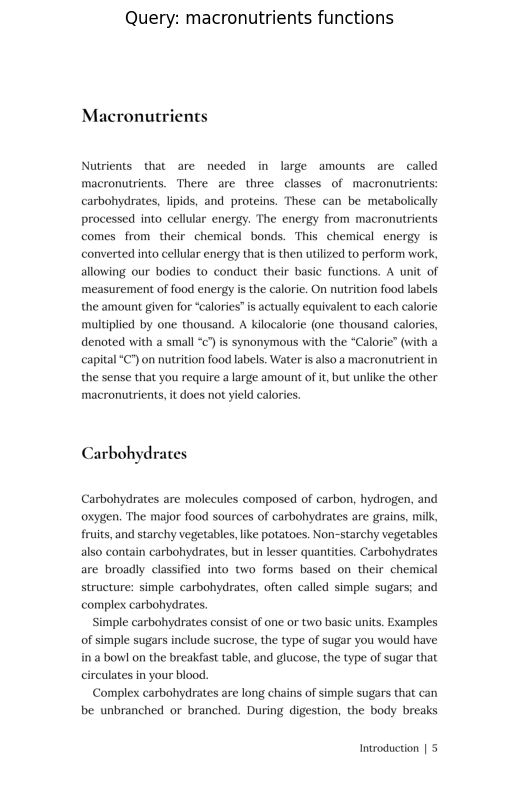

In [39]:
import fitz

pdf_path = "human-nutrition-text.pdf"
doc = fitz.open(pdf_path)
page = doc.load_page(5 + 41)

img = page.get_pixmap(dpi=300)

doc.close()

img_array = np.frombuffer(img.samples_mv, dtype=np.uint8).reshape((img.h, img.w, img.n))

import matplotlib.pyplot as plt

plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: {query}")
plt.axis("off")

In [40]:
def retrieve_relevant_resources(
    query: str,
    embeddings: torch.tensor,
    model: SentenceTransformer=embedding_model,
    n_resources_to_return: int=5,
    print_time: bool=True
):
    
    query_embedding = model.encode(query, convert_to_tensor=True)
    start_time = timer()

    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    scores, indices = torch.topk(input=dot_scores, k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(
    query: str,
    embeddings: torch.tensor,
    pages_and_chunks: list[dict] = pages_and_chunks_over_min_token_len,
    n_resources_to_return: int = 5
):
    scores, indices = retrieve_relevant_resources(
        query=query,
        embeddings=embeddings,
        n_resources_to_return=n_resources_to_return
    )

    for score, idx in zip(scores, indices):
        print(f"Score: {score}")
        print_wrapped("Text:")
        print(pages_and_chunks[idx]["sentence_chunk"])
        print(f"Page number: {pages_and_chunks[idx]['page_number']}")
        print("\n")

In [41]:
query = "foods high in fiber"
print_top_results_and_scores(query=query, embeddings=embeddings)

Score: 0.6963627934455872
Text:
• Change it up a bit and experience the taste and satisfaction of other whole grains such as barley, quinoa, and bulgur. • Eat snacks high in fiber, such as almonds, pistachios, raisins, and air-popped popcorn. Add an artichoke and green peas to your dinner plate more 276 | Carbohydrates and Personal Diet Choices
Page number: 276


Score: 0.6809899210929871
Text:
Dietary fiber is categorized as either water-soluble or insoluble. Some examples of soluble fibers are inulin, pectin, and guar gum and they are found in peas, beans, oats, barley, and rye. Cellulose and lignin are insoluble fibers and a few dietary sources of them are whole-grain foods, flax, cauliflower, and avocados. Cellulose is the most abundant fiber in plants, making up the cell walls and providing structure. Soluble fibers are more easily accessible to bacterial enzymes in the large intestine so they can be broken down to a greater extent than insoluble fibers, but even some breakdown of

In [42]:
import torch 
from transformers import AutoTokenizer, AutoModelForCausalLM

attn_implementation = "sdpa"
print(f"[INFO] Using attention implementation: {attn_implementation}")

model_id = "google/gemma-2b-it"
print(f"[INFO] Using model_id: {model_id}")

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_id)

llm_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=model_id,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    attn_implementation=attn_implementation
)

llm_model.to("mps")
print("[INFO] Model successfully loaded onto MPS (Apple Silicon GPU)")

[INFO] Using attention implementation: sdpa
[INFO] Using model_id: google/gemma-2b-it


/Users/nickol/My Fucking Stuff/machine learning/code/local-rag/venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[INFO] Model successfully loaded onto MPS (Apple Silicon GPU)


In [43]:
llm_model

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaSdpaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): GemmaRotaryEmbedding()
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm()
        (post_attention_layernorm): GemmaRMSNorm()
      )
    )
    (norm): GemmaRM

In [44]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])

get_model_num_params(llm_model)

2506172416

In [45]:
tensor = torch.randn(512, 512)

tensor.shape, tensor.dtype

(torch.Size([512, 512]), torch.float32)

In [46]:
tensor.numel()

262144

In [47]:
tensor.nelement()

262144

In [48]:
tensor.element_size()

4

In [49]:
def get_model_mem_size(model: torch.nn.Module):
    mem_params = sum([param.nelement() * param.element_size() for param in model.parameters()])
    mem_buffers = sum([buf.nelement() * buf.element_size() for buf in model.buffers()])

    model_mem_bytes = mem_params + mem_buffers
    model_mem_kb = model_mem_bytes / 1024
    model_mem_mb = model_mem_bytes / (1024**2)
    model_mem_gb = model_mem_bytes / (1024**3)

    return {
        "model_mem_bytes": model_mem_bytes,
        "model_mem_kb": model_mem_kb,
        "model_mem_mb": round(model_mem_mb, 2),
        "model_mem_gb": round(model_mem_gb, 2),
    }

get_model_mem_size(llm_model)


{'model_mem_bytes': 5079453696,
 'model_mem_kb': 4960404.0,
 'model_mem_mb': 4844.14,
 'model_mem_gb': 4.73}

In [50]:
input_text = "Who is the best fotballer of all time?"
print(f"Input:\n{input_text}\n")

dialogue_template = [
    {
        "role": "user",
        "content": input_text
    }
]

prompt = tokenizer.apply_chat_template(
    conversation=dialogue_template,
    tokenize=False,
    add_generation_prompt=True
)

print(f"Prompt:\n{prompt}")

Input:
Who is the best fotballer of all time?

Prompt:
<bos><start_of_turn>user
Who is the best fotballer of all time?<end_of_turn>
<start_of_turn>model



In [51]:
tokenizer

GemmaTokenizerFast(name_or_path='google/gemma-2b-it', vocab_size=256000, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'pad_token': '<pad>', 'additional_special_tokens': ['<start_of_turn>', '<end_of_turn>']}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<eos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<bos>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	4: AddedToken("<mask>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=False),
	5: AddedToken("<2mass>", rstrip=False, lstrip=False, single_w

In [52]:
input_ids = tokenizer(
    prompt,
    return_tensors="pt"
).to("mps")

outputs = llm_model.generate(
    **input_ids,
    max_new_tokens=256
)

outputs

tensor([[     2,      2,    106,   1645,    108,   6571,    603,    573,   1963,
          34707,  94361,    576,    832,   1069, 235336,    107,    108,    106,
           2516,    108, 180440,    573,   6943,    664,   8351, 235281,  80612,
            576,    832,   1069,    603,   7475,  45927,    578,  12014,    611,
           4282,   7549, 235269,   3359, 235292,    109,    688,  36872, 111998,
          66058,    109, 235287,   5231,  48974,  66058,  82853,  50375,  11845,
            573,    832, 235290,   1602,  21949,  12859,    675, 235248, 235321,
         235304, 235324,   9082,    575, 235248, 235321, 235315, 235284,   5178,
         235265,    108, 235287,   5231,  20119,  20103,  66058,  19425, 235303,
         235256,  19465, 235335,  12723,    573,   3661,    604,   1546,   6191,
           9082,    591, 235274, 235269, 235310, 235276, 235304, 235275,    578,
          37876,    591, 235274, 235269, 235304, 235318, 235304,    846,    108,
         235287,   5231,  30

In [53]:
outputs_decoded = tokenizer.decode(outputs[0])
print(f"Model output (decoded):\n{outputs_decoded}\n")

Model output (decoded):
<bos><bos><start_of_turn>user
Who is the best fotballer of all time?<end_of_turn>
<start_of_turn>model
Determining the absolute "best" footballer of all time is highly subjective and depends on various factors, including:

**Individual Achievements:**

* **Goals:** Cristiano Ronaldo leads the all-time scoring chart with 837 goals in 892 games.
* **International Success:** Brazil's Pelé holds the record for most international goals (1,403) and appearances (1,363).
* **Ball Skills:** Lionel Messi is widely considered one of the greatest dribblers and playmakers of all time.
* **Leadership:** Messi and Ronaldo have both won the Ballon d'Or, the most prestigious individual award in football.

**Team Success:**

* **Champions League wins:** Bayern Munich's Bayern Munich has the most Champions League titles (13) and is tied with Barcelona for second (10).
* **International trophies:** Brazil's national team has won 19 FIFA World Cup titles, the most by any nation.
* *

In [54]:
gpt4_questions = [
    "What are the macronutrients, and what roles do they play in the human body?",
    "How do vitamins and minerals differ in their roles and importance for health?",
    "Describe the process of digestion and absorption of nutrients in the human body.",
    "What role does fibre play in digestion? Name five fibre containing foods.",
    "Explain the concept of energy balance and its importance in weight management."
]

manual_questions = [
    "How often should infants be breastfed?",
    "What are symptoms of pellagra?",
    "How does saliva help with digestion?",
    "What is the RDI for protein per day?",
    "water soluble vitamins"
]

query_list = gpt4_questions + manual_questions

In [55]:
import random

query = random.choice(query_list)

scores, indices = retrieve_relevant_resources(query, embeddings)

scores, indices

(tensor([0.7302, 0.7233, 0.6962, 0.6942, 0.6416], device='mps:0'),
 tensor([42, 47, 46, 41, 52], device='mps:0'))

In [56]:
pages_and_chunks = pages_and_chunks_over_min_token_len

In [62]:
def prompt_formatter(
        query: str,
        context_items: list[dict]
):
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

    base_prompt = """Based on the following context items, please answer the query.
Context items:
{context}
Query: {query}
Answer:
"""

    prompt = base_prompt.format(context=context, query=query)

    return prompt


query = random.choice(query_list)

print(f"Query: {query}")

scores, indices = retrieve_relevant_resources(query, embeddings)

context_items = [pages_and_chunks[i] for i in indices]

prompt = prompt_formatter(query=query, context_items=context_items)

print(f"Prompt: {prompt}")

Query: How often should infants be breastfed?
Prompt: Based on the following context items, please answer the query.
Context items:
- milk is the best source to fulfill nutritional requirements. An exclusively breastfed infant does not even need extra water, including in hot climates. A newborn infant (birth to 28 days) requires feedings eight to twelve times a day or more. Between 1 and 3 months of age, the breastfed infant becomes more efficient, and the number of feedings per day often become fewer even though the amount of milk consumed stays the same. After about six months, infants can gradually begin to consume solid foods to help meet nutrient needs. Foods that are added in addition to breastmilk are called complementary foods. Complementary foods should be nutrient dense to provide optimal nutrition. Complementary foods include baby meats, vegetables, fruits, infant cereal, and dairy products such as yogurt, but not infant formula. Infant formula is a substitute, not a complem

In [63]:
input_ids = tokenizer(prompt, return_tensors="pt").to("mps")

outputs = llm_model.generate(
    **input_ids,
    temperature=1,
    do_sample=True,
    max_new_tokens=256
)

output_text = tokenizer.decode(outputs[0])
print(f"Query: {query}")
print(f"RAG answer:\m{output_text}")

Query: How often should infants be breastfed?
RAG answer:\m<bos>Based on the following context items, please answer the query.
Context items:
- milk is the best source to fulfill nutritional requirements. An exclusively breastfed infant does not even need extra water, including in hot climates. A newborn infant (birth to 28 days) requires feedings eight to twelve times a day or more. Between 1 and 3 months of age, the breastfed infant becomes more efficient, and the number of feedings per day often become fewer even though the amount of milk consumed stays the same. After about six months, infants can gradually begin to consume solid foods to help meet nutrient needs. Foods that are added in addition to breastmilk are called complementary foods. Complementary foods should be nutrient dense to provide optimal nutrition. Complementary foods include baby meats, vegetables, fruits, infant cereal, and dairy products such as yogurt, but not infant formula. Infant formula is a substitute, not